# **Business Case: Walmart - Confidence Interval and CLT**

##**Submitted By: Aravinth Baskar**

# 1. Business Problem

Walmart wants to understand customer purchase behavior during Black Friday and determine whether
spending patterns differ across different customer segments.

The primary objective is to compare the purchase amounts of male and female customers and answer
the question:

**Do women spend more per transaction than men?**

Along with gender, we will also analyze purchase behavior based on marital status and age groups.
We will further use the Central Limit Theorem and Confidence Intervals to understand how the sample
findings can be generalized to the larger customer population.

**Assumption:** The dataset available to us is a sample of transactions. The business assumes the
actual customer base consists of 50 million male customers and 50 million female customers. We will
use the sample mean, standard deviation and the Central Limit Theorem to construct confidence intervals for the population mean purchase amount per transaction and use these results to answer the business question at the
population level.

Based on the findings, the objective is to provide simple and actionable recommendations that can
help Walmart make better business decisions.



# 2. Dataset Description

The dataset contains transactional data of customers who made purchases at Walmart stores during the Black Friday sale.

It contains information about the customers, their demographic characteristics, the products they purchased, and the amount spent on each transaction.

The main variables available in the dataset are:

| Variable | Description |
|---|---|
| User_ID | User ID |
| Product_ID | Product ID |
| Gender | Sex of User |
| Age | Age in bins |
| Occupation | Occupation (Masked) |
| City_Category | Category of the City (A, B, C) |
| StayInCurrentCityYears | Number of years stay in current city |
| Marital_Status | Marital Status |
| ProductCategory | Product Category (Masked) |
| Purchase | Purchase Amount |

# 3. Importing Required Libraries



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

# 4. Reading the Dataset



In [ ]:
!gdown 1YdtU9mINqEnfvMF5FW9ko7rGWn0_F6xv

Downloading...
From: https://drive.google.com/uc?id=1YdtU9mINqEnfvMF5FW9ko7rGWn0_F6xv
To: /content/walmart_data.csv
100% 23.0M/23.0M [00:00<00:00, 172MB/s]


In [ ]:
df = pd.read_csv("walmart_data.csv")

# 5. Non-Graphical Analysis

## 5.1 Initial Data Inspection



In [ ]:
df.head(3)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422


## 5.2 Shape of the Dataset



In [ ]:
df.shape

(550068, 10)

## 5.3 Dataset Information


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


## 5.4 Data Type Conversion

Some variables in the dataset represent categorical information even though they may initially be stored as an object or integer data type. Converting these variables to the category datatype makes their nature explicit and can also improve memory efficiency.



In [ ]:
categorical_columns = ["Gender", "Age", "Occupation", "City_Category",
"Stay_In_Current_City_Years", "Marital_Status", "Product_Category"]

df[categorical_columns] = df[categorical_columns].astype("category")

df.dtypes

,0
User_ID,int64
Product_ID,object
Gender,category
Age,category
Occupation,category
City_Category,category
Stay_In_Current_City_Years,category
Marital_Status,category
Product_Category,category
Purchase,int64


## 5.5 Unique Values and Value Counts



In [ ]:
df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [ ]:
for i in categorical_columns:
  print(df[i].value_counts())
  print("---"*10)


Gender
M    414259
F    135809
Name: count, dtype: int64
------------------------------
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64
------------------------------
Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: count, dtype: int64
------------------------------
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64
------------------------------
Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64
------------------------------
Marital_Status
0    324731
1    225337
Name: count, dtype: int64
------------------------------
Product_Category
5     150933
1     140378
8     113925
11     2428

## 5.6 Missing Values



In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


## 5.7 Duplicate Records



In [ ]:
df.duplicated().sum()


np.int64(0)

## 5.8 Statistical Summary


In [ ]:
df.describe()

,User_ID,Purchase
count,5.500680e+05,550068.000000
mean,1.003029e+06,9263.968713
std,1.727592e+03,5023.065394
min,1.000001e+06,12.000000
25%,1.001516e+06,5823.000000
50%,1.003077e+06,8047.000000
75%,1.004478e+06,12054.000000
max,1.006040e+06,23961.000000


## 5.9 Insights from Non-Graphical Analysis

- The dataset contains 550068 rows and 10 columns, representing transaction-level purchase data.

- The dataset contains no missing values, so no missing-value treatment is required.

- There are no duplicate records in the dataset.

- The dataset contains both numerical and categorical attributes. Categorical attributes were converted to the category datatype where appropriate.

- The categorical variables contain multiple customer segments including gender, age groups, occupation, city category, marital status, and years of stay in the current city.

- From the statistical summary, the Purchase variable shows a difference between its mean and median, which indicates that the distribution may not be perfectly symmetric.


# 6. Outlier Analysis

Outlier analysis is performed on the Purchase variable to identify unusually high or low purchase amounts that may affect the analysis.



## 6.1 Boxplot of Purchase




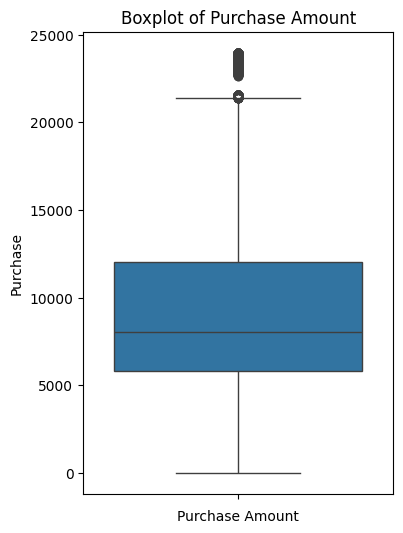

In [ ]:
plt.figure(figsize = (4,6))
sns.boxplot(df["Purchase"])
plt.title("Boxplot of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.show()

## 6.2 IQR-Based Outlier Detection


In [ ]:
Q1 = df["Purchase"].quantile(0.25)
Q3 = df["Purchase"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 5823.0
Q3: 12054.0
IQR: 6231.0
Lower Limit: -3523.5
Upper Limit: 21400.5


In [ ]:
outliers = df[(df["Purchase"] > upper_limit)]
print("Number of outliers:", len(outliers))

Number of outliers: 2677


## 6.3 Outlier Proportion



In [ ]:
outlier_percentage = round(((len(outliers) / len(df)) * 100),2)
print("Outlier Percentage:", outlier_percentage)

Outlier Percentage: 0.49


## 6.4 Outlier Analysis Conclusion

The IQR method identified 2,677 outlier transactions, which account for approximately 0.49% of the total dataset.

Since these observations represent actual purchase transactions and may correspond to genuine high-value purchases during the Black Friday sale, they will not be removed from the analysis.

The outliers will be retained so that the analysis reflects the actual purchasing behavior of Walmart customers.

#7. Univariate Analysis

## 7.1 Distribution of Purchase



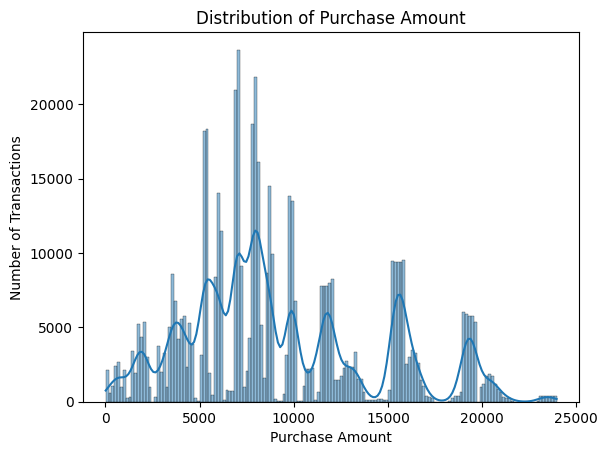

In [ ]:
sns.histplot(data=df, x="Purchase", kde=True)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Transactions")
plt.show()

### Observation

- The Purchase distribution is not symmetric and shows multiple peaks across different purchase ranges. The distribution is also right-skewed, with a relatively small number of transactions having very high purchase amounts.

- This indicates that purchase amounts vary considerably across transactions and may be influenced by different customer or product segments.

## 7.2 Gender Distribution


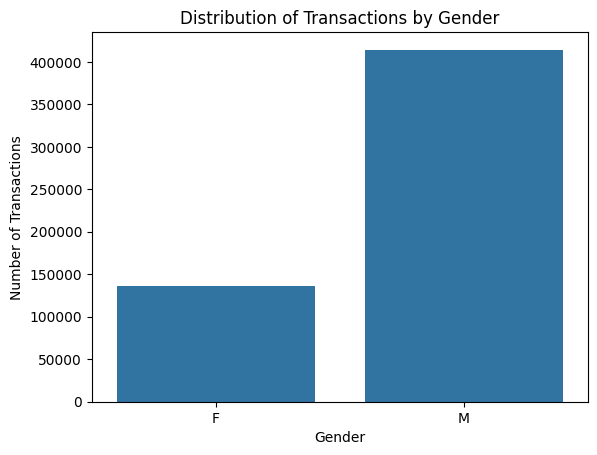

In [ ]:
sns.countplot(data=df, x="Gender")
plt.title("Distribution of Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.show()

### Observation

- The dataset contains considerably more transactions from male customers than female customers.

- This indicates that the sample is not evenly distributed by gender. Therefore, when comparing male and female purchase amounts, we should focus on the average purchase amount and its uncertainty.

## 7.3 Age Distribution


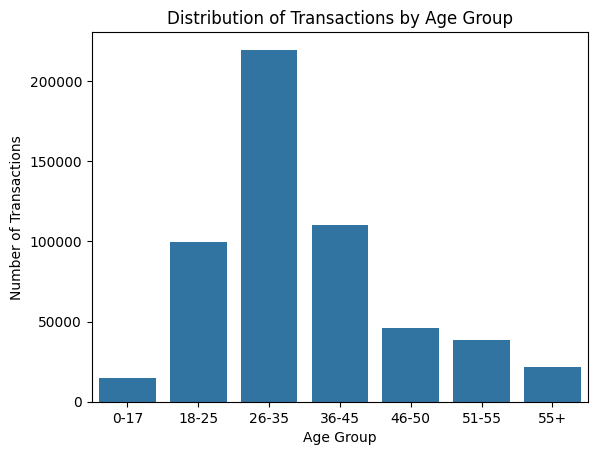

In [ ]:
sns.countplot(data=df, x="Age")
plt.title("Distribution of Transactions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.show()

### Observation

- The 26–35 age group accounts for the highest number of transactions in the dataset, followed by the 36–45 and 18–25 age groups.

- The 0–17 age group has the lowest number of transactions. Overall, the dataset is concentrated more among customers aged 18–45.

## 7.4 Marital Status Distribution


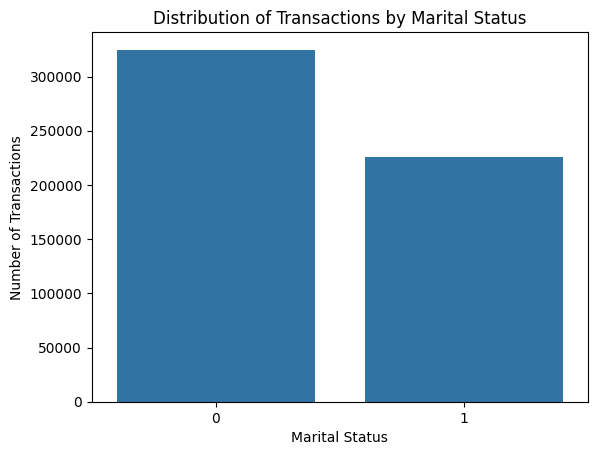

In [ ]:
sns.countplot(data=df, x="Marital_Status")
plt.title("Distribution of Transactions by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Transactions")
plt.show()

### Observation

- The dataset contains more transactions from unmarried compared to married.

- This shows that the sample is not evenly distributed by marital status. Therefore, the comparison of purchase amounts between married and unmarried customers should be based on measures such as average purchase and confidence intervals rather than transaction counts alone.

# 8. Bivariate Analysis



## 8.1 Purchase Amount by Gender


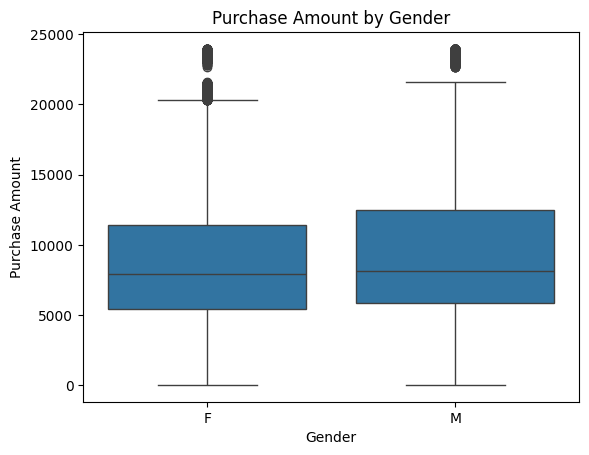

In [ ]:
sns.boxplot(data=df, x="Gender", y="Purchase")
plt.title("Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount")
plt.show()

In [ ]:
df.groupby("Gender", observed = True)["Purchase"].mean().reset_index()

,Gender,Purchase
0,F,8734.565765
1,M,9437.526040


### Observation

- The boxplot shows that the purchase amount distributions of male and female customers overlap considerably.

- The median purchase amount for male customers appears slightly higher than that of female customers. Both groups also show considerable variation and contain high-value outliers.

- The average purchase amount is also higher for male customers, with an average purchase of approximately ₹9,438 compared with approximately ₹8,735 for female customers.



## 8.2 Purchase Amount by Age Group


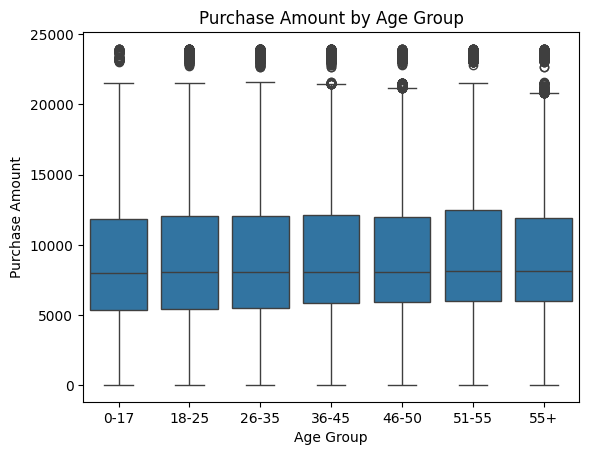

In [ ]:
sns.boxplot(data=df, x="Age", y="Purchase")
plt.title("Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")
plt.show()

In [ ]:
df.groupby("Age", observed = True)["Purchase"].mean().reset_index()

,Age,Purchase
0,0-17,8933.464640
1,18-25,9169.663606
2,26-35,9252.690633
3,36-45,9331.350695
4,46-50,9208.625697
5,51-55,9534.808031
6,55+,9336.280459


### Observation

- The purchase amount distributions across the age groups show considerable overlap, with similar levels of variation and high-value outliers across the groups.

- The average purchase amount is highest for the 51–55 age group (approximately ₹9,535) and lowest for the 0–17 age group (approximately ₹8,933).

- Although there are differences in average purchase amount across age groups, the differences are relatively small compared with the overall variation within each group.

##8.3 Purchase Amount by Marital Status

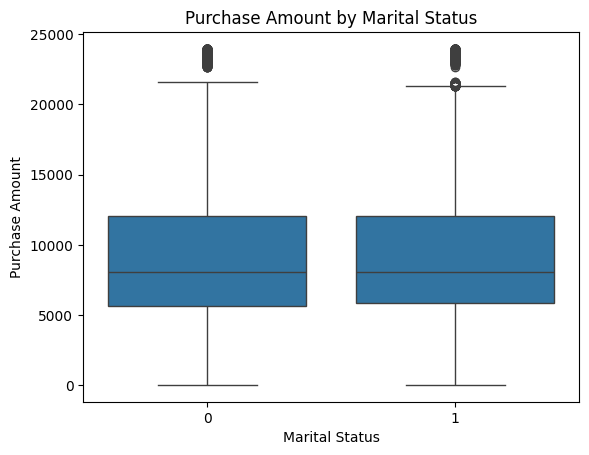

In [ ]:
sns.boxplot(data=df, x="Marital_Status", y="Purchase")
plt.title("Purchase Amount by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Purchase Amount")
plt.show()

In [ ]:
df.groupby("Marital_Status", observed = True)["Purchase"].mean().reset_index()

,Marital_Status,Purchase
0,0,9265.907619
1,1,9261.174574


### Observation

- The boxplot shows that the purchase amount distributions of married and unmarried customers are very similar.

- The median purchase amounts are nearly identical, and both groups show similar variation and high-value outliers.

- The average purchase amount is also almost the same, with unmarried customers spending approximately ₹9,266 per transaction compared with approximately ₹9,261 for married customers.

- Overall, there is very little difference in purchase amount between married and unmarried customers in the sample.

##8.4 Gender Distribution by Marital Status

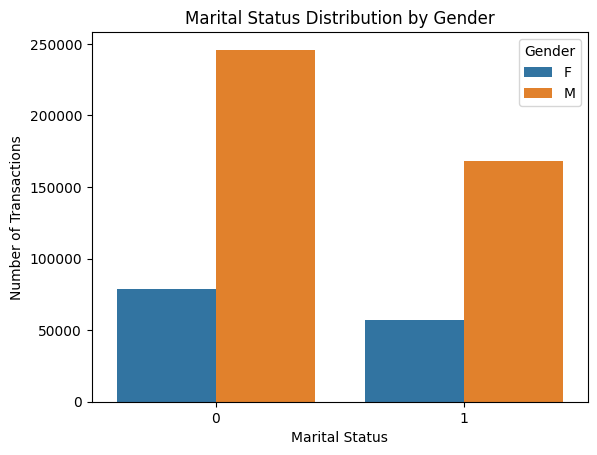

In [ ]:
sns.countplot(data=df, x="Marital_Status", hue="Gender")
plt.title("Marital Status Distribution by Gender")
plt.xlabel("Marital Status")
plt.ylabel("Number of Transactions")
plt.show()

###Observation

- Across both marital status categories, male customers account for a considerably higher number of transactions than female customers.
- The proportion of married vs unmarried transactions looks similar within both gender groups, suggesting no strong interaction between gender and marital status in terms of transaction volume.

## 8.5 Combined Demographic Analysis

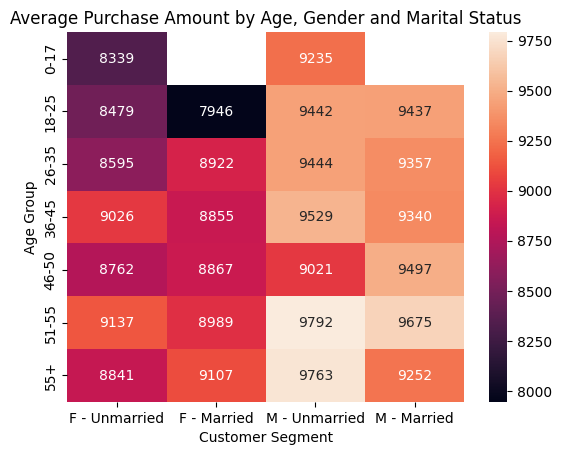

In [ ]:
heatmap_data = df.pivot_table(values="Purchase", index="Age", columns=["Gender", "Marital_Status"],
aggfunc="mean", observed=True)

heatmap_data.columns = [f"{gender} - {'Married' if status == 1 else 'Unmarried'}"
for gender, status in heatmap_data.columns]

sns.heatmap(heatmap_data, annot=True, fmt=".0f")

plt.title("Average Purchase Amount by Age, Gender and Marital Status")
plt.xlabel("Customer Segment")
plt.ylabel("Age Group")
plt.show()

### Observation

- Male customers generally have higher average purchase amounts than female customers across most age and marital-status segments.

- The 51–55 male-unmarried segment has the highest average purchase amount at approximately 9,792.

- The 18–25 female-married segment has the lowest average purchase amount at approximately 7,946.

- The difference between married and unmarried customers within the same gender and age group is generally smaller than the difference observed between male and female customers.


## 8.6 Note on Correlation Analysis

A traditional correlation matrix or pairplot is not meaningful for this dataset, since almost all
variables (Gender, Age, City_Category, Marital_Status, Occupation, Product_Category) are categorical,
and Purchase is the only continuous variable. Computing Pearson correlation between a single continuous
variable and itself adds no information.

Instead, we used a pivot-table heatmap (Section 8.4) to examine how the mean of the continuous variable
(Purchase) varies across combinations of categorical variables (Age, Gender, Marital Status), which is
the appropriate way to explore relationships here.

#9. Statistical Inference

##9.1 Male vs Female

### 9.1.1 Sample Statistics

Before applying the Central Limit Theorem, we first calculate the sample size, average purchase amount and standard deviation for male and female customers.

In [ ]:
gender_stats = df.groupby("Gender", observed = True)["Purchase"].agg(Sample_Size="count", Mean="mean", Std_Dev="std").reset_index()
print(gender_stats)

  Gender  Sample_Size         Mean      Std_Dev
0      F       135809  8734.565765  4767.233289
1      M       414259  9437.526040  5092.186210


###9.1.2 Central Limit Theorem

The Central Limit Theorem states that the distribution of sample means tends to become approximately normal as the sample size increases, even when the underlying population distribution is not normally distributed.

To demonstrate this, we repeatedly draw random samples of size 30 from the male and female purchase data and calculate the mean of each sample.

In [ ]:
female_purchase = df[df["Gender"] == "F"]["Purchase"]
male_purchase = df[df["Gender"] == "M"]["Purchase"]

sample_size = 30
num_samples = 1000

female_means = []
male_means = []

for i in range(num_samples):
    female_sample = np.random.choice(female_purchase, size=sample_size)
    male_sample = np.random.choice(male_purchase, size=sample_size)

    female_means.append(female_sample.mean())
    male_means.append(male_sample.mean())

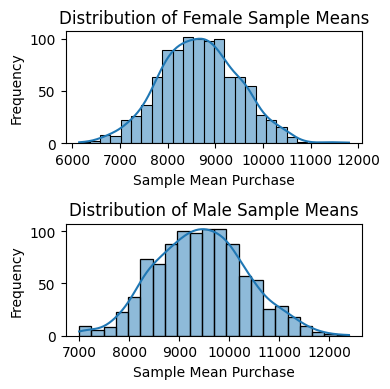

In [ ]:
plt.figure(figsize=(4, 4))

plt.subplot(2, 1, 1)
sns.histplot(female_means, kde=True)
plt.title("Distribution of Female Sample Means")
plt.xlabel("Sample Mean Purchase")
plt.ylabel("Frequency")

plt.subplot(2, 1, 2)
sns.histplot(male_means, kde=True)
plt.title("Distribution of Male Sample Means")
plt.xlabel("Sample Mean Purchase")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 9.1.3 Effect of Sample Size on Distribution of Sample Mean

To observe the effect of sample size, we repeatedly draw random samples of different sizes from the male and female purchase data and calculate the sample mean for each sample.


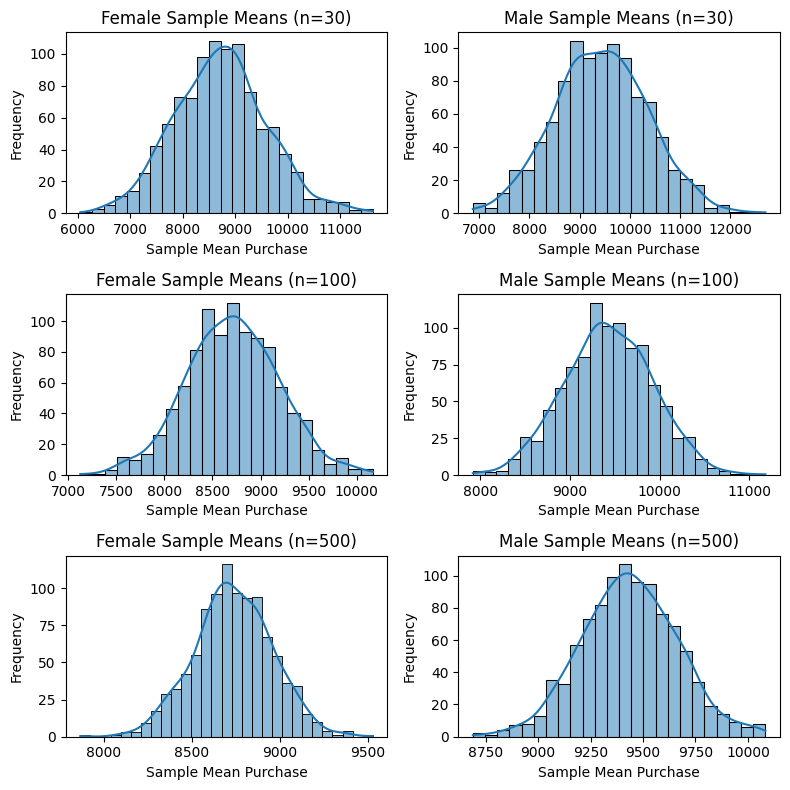

In [ ]:
sample_sizes = [30, 100, 500]

plt.figure(figsize=(8, 8))

for i, sample_size in enumerate(sample_sizes):

    female_means = []
    male_means = []

    for j in range(1000):
        female_sample = np.random.choice(female_purchase, size=sample_size)
        male_sample = np.random.choice(male_purchase, size=sample_size)

        female_means.append(female_sample.mean())
        male_means.append(male_sample.mean())

    plt.subplot(3, 2, 2*i + 1)
    sns.histplot(female_means, kde=True)
    plt.title(f"Female Sample Means (n={sample_size})")
    plt.xlabel("Sample Mean Purchase")
    plt.ylabel("Frequency")

    plt.subplot(3, 2, 2*i + 2)
    sns.histplot(male_means, kde=True)
    plt.title(f"Male Sample Means (n={sample_size})")
    plt.xlabel("Sample Mean Purchase")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 9.1.4 Confidence Intervals

We now estimate the range within which the true population mean purchase amount is expected to lie.

Since the male and female sample sizes are very large, we use the standard normal (Z) distribution to calculate the confidence intervals.

Confidence intervals are calculated at 90%, 95%, and 99% confidence levels.

In [ ]:
from scipy.stats import norm

purchase_male = df[df["Gender"] == "M"]["Purchase"]
male_mean = purchase_male.mean()
male_sd = purchase_male.std()
male_count = len(purchase_male)
std_err = male_sd/np.sqrt(male_count)

confidence = [0.9, 0.95, 0.99]
male_limits = {}
for i in confidence:
  l = (1-i)/2
  z = norm.ppf(1-l)
  lhs = z*std_err
  upper = male_mean + lhs
  lower = male_mean - lhs
  male_limits[i] = [upper, lower]

male_result = pd.DataFrame(male_limits).T.reset_index()
male_result.columns = ["Confidence_Level","Male_Upper_Limit", "Male_Lower_Limit"]

purchase_female = df[df["Gender"] == "F"]["Purchase"]
female_mean = purchase_female.mean()
female_sd = purchase_female.std()
female_count = len(purchase_female)
std_err = female_sd/np.sqrt(female_count)

female_limits = {}
for i in confidence:
  l = (1-i)/2
  z = norm.ppf(1-l)
  lhs = z*std_err
  upper = female_mean + lhs
  lower = female_mean - lhs
  female_limits[i] = [upper, lower]

female_result = pd.DataFrame(female_limits).T.reset_index()
female_result.columns = ["Confidence_Level","female_Upper_Limit", "female_Lower_Limit"]

final_result = pd.merge(male_result, female_result, on = "Confidence_Level")

print(final_result)



   Confidence_Level  Male_Upper_Limit  Male_Lower_Limit  female_Upper_Limit  \
0              0.90       9450.539584       9424.512497         8755.843696   
1              0.95       9453.032634       9422.019447         8759.919983   
2              0.99       9457.905158       9417.146923         8767.886856   

   female_Lower_Limit  
0         8713.287835  
1         8709.211547  
2         8701.244674  


### 9.1.5 Hypothesis Test — Two-Sample One-Tailed Z-Test

Now we formally test whether male customers have a higher average purchase amount than female customers.

#### Hypotheses

- H₀: μₘ ≤ μ𝒻  
  The average purchase amount of male customers is not higher than that of female customers.

- H₁: μₘ > μ𝒻  
  The average purchase amount of male customers is higher than that of female customers.

A two-sample one-tailed Z-test is used at a 10%, 5% and 1% significance level.



In [ ]:
from statsmodels.stats.weightstats import ztest

z_stats, p_value = ztest(purchase_male, purchase_female, alternative = "larger")

print(f"Z_stats = {z_stats} , P_value = {p_value}")

Z_stats = 44.837957934353966 , P_value = 0.0


### 9.1.6 Conclusion

- The analysis of male and female customers shows that male customers have a higher average purchase amount than female customers.

- The sample means were approximately ₹9,438 for male customers and ₹8,735 for female customers. The CLT demonstration showed that as sample size increases, the distribution of sample means becomes narrower and more concentrated around the population mean.

- **The confidence intervals at 90%, 95%, and 99% did not overlap, with the male confidence interval remaining completely above the female confidence interval at all three confidence levels.**

- The two-sample one-tailed Z-test also resulted in a p-value approximately equal to 0, which is below the significance levels of 10%, 5%, and 1%. Therefore, the null hypothesis was rejected at all three significance levels.

- Hence, there is strong statistical evidence that male customers spend more per transaction than female customers during the Black Friday sale.

Therefore, the answer to the primary business question is:

**Women do not spend more than men on average; male customers have a significantly higher average purchase amount.**

## 9.2 Age Group Analysis

### 9.2.1 Creating the Required Age Groups

The dataset contains age categories that are more detailed than the age groups specified in the assignment. Therefore, the existing categories are combined into the five required age groups.

The required age groups are:

- 0–17
- 18–25
- 26–35
- 36–50
- 51+

A new Age_Group column is created while retaining the original Age column.



In [ ]:
age_mapping = {
    "0-17": "0-17",
    "18-25": "18-25",
    "26-35": "26-35",
    "36-45": "36-50",
    "46-50": "36-50",
    "51-55": "51+",
    "55+": "51+"
}

df["Age_Group"] = df["Age"].map(age_mapping)

df["Age_Group"].value_counts()

,count
Age_Group,
26-35,219587
36-50,155714
18-25,99660
51+,60005
0-17,15102


### 9.2.2 Sample Statistics

We calculate the sample size, average purchase amount, and standard deviation for each age group to understand the purchasing behavior and variability within each group.

In [ ]:
age_stats = df.groupby("Age_Group", observed= True)["Purchase"].agg(
Sample_Size="count", Mean="mean", Std_Dev="std").reset_index()

print(age_stats)

  Age_Group  Sample_Size         Mean      Std_Dev
0      0-17        15102  8933.464640  5111.114046
1     18-25        99660  9169.663606  5034.321997
2     26-35       219587  9252.690633  5010.527303
3     36-50       155714  9295.331743  5006.934324
4       51+        60005  9463.661678  5061.161476


### 9.2.3 CLT Demonstration for Age Groups

The same Central Limit Theorem behavior observed for Gender also holds for other segments. To confirm
this, we repeat the sampling exercise for two Age Groups with the largest difference in mean purchase
— "0-17" (lowest) and "51+" (highest) — and observe how their sample-mean distributions behave as
sample size increases.

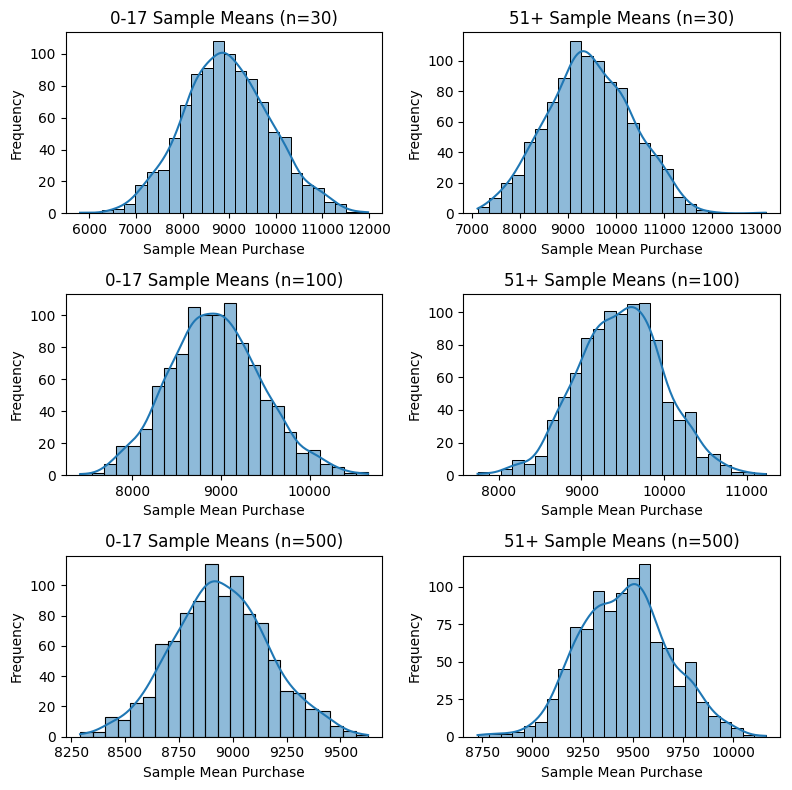

In [ ]:
purchase_0_17 = df[df["Age_Group"] == "0-17"]["Purchase"]
purchase_51_plus = df[df["Age_Group"] == "51+"]["Purchase"]

sample_sizes = [30, 100, 500]

plt.figure(figsize=(8, 8))

for i, sample_size in enumerate(sample_sizes):
    means_0_17 = []
    means_51_plus = []

    for j in range(1000):
        sample_0_17 = np.random.choice(purchase_0_17, size=sample_size)
        sample_51_plus = np.random.choice(purchase_51_plus, size=sample_size)

        means_0_17.append(sample_0_17.mean())
        means_51_plus.append(sample_51_plus.mean())

    plt.subplot(3, 2, 2*i + 1)
    sns.histplot(means_0_17, kde=True)
    plt.title(f"0-17 Sample Means (n={sample_size})")
    plt.xlabel("Sample Mean Purchase")
    plt.ylabel("Frequency")

    plt.subplot(3, 2, 2*i + 2)
    sns.histplot(means_51_plus, kde=True)
    plt.title(f"51+ Sample Means (n={sample_size})")
    plt.xlabel("Sample Mean Purchase")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 9.2.4 Confidence Intervals

Since all five age groups have large sample sizes, the Z-distribution is used to calculate the confidence intervals for the mean purchase amount.

Confidence intervals are calculated at 90%, 95%, and 99% confidence levels for each age group.



In [ ]:
from scipy.stats import norm

confidence = [0.90, 0.95, 0.99]

age_ci = {}

for age_group in df["Age_Group"].unique():

    age_purchase = df[df["Age_Group"] == age_group]["Purchase"]

    mean = age_purchase.mean()
    sd = age_purchase.std()
    count = len(age_purchase)

    std_err = sd / np.sqrt(count)

    age_ci[age_group] = {}

    for i in confidence:

        l = (1 - i) / 2
        z = norm.ppf(1 - l)

        margin = z * std_err

        upper = mean + margin
        lower = mean - margin

        age_ci[age_group][i] = [upper, lower]

age_result = []

for age_group in age_ci:

    for confidence_level in confidence:

        upper = age_ci[age_group][confidence_level][0]
        lower = age_ci[age_group][confidence_level][1]

        age_result.append([
            age_group,
            confidence_level,
            upper,
            lower
        ])

age_result = pd.DataFrame(
    age_result,
    columns=[
        "Age_Group",
        "Confidence_Level",
        "Upper_Limit",
        "Lower_Limit"
    ]
)

age_result

,Age_Group,Confidence_Level,Upper_Limit,Lower_Limit
0,0-17,0.90,9001.875586,8865.053695
1,0-17,0.95,9014.981310,8851.947971
2,0-17,0.99,9040.595704,8826.333576
3,51+,0.90,9497.646401,9429.676956
4,51+,0.95,9504.156973,9423.166383
5,51+,0.99,9516.881517,9410.441840
6,26-35,0.90,9270.278265,9235.103001
7,26-35,0.95,9273.647589,9231.733676
8,26-35,0.99,9280.232742,9225.148523
9,36-50,0.90,9316.202361,9274.461124


### 9.2.5 Hypothesis Test — Is the Highest Mean Significantly Higher?

The 51+ age group has the highest average purchase amount, while the 36–50 age group has the next highest average.

To determine whether the higher average purchase amount of customers aged 51+ is statistically significant, a **two-sample one-tailed Z-test** is performed.

- H₀: μ₅₁₊ ≤ μ₃₆₋₅₀
- H₁: μ₅₁₊ > μ₃₆₋₅₀

In [ ]:
purchase_51_plus = df[df["Age_Group"] == "51+"]["Purchase"]
purchase_36_50 = df[df["Age_Group"] == "36-50"]["Purchase"]

z_stats, p_value = ztest(purchase_51_plus, purchase_36_50, alternative="larger")

print(f"Z-stat = {z_stats}, P-value = {p_value}")

Z-stat = 6.975756995938636, P-value = 1.5211409532523082e-12


### 9.2.6 Hypothesis Test — Confidence Interval Overlap — 26–35 vs 36–50

The 26–35 and 36–50 age groups have overlapping confidence intervals at the 99% confidence level. Their average purchase amounts are also very close.

Therefore, a two-sample one-tailed Z-test is performed to determine whether customers aged 36–50 have a significantly higher average purchase amount than customers aged 26–35.

- H₀: μ₃₆₋₅₀ ≤ μ₂₆₋₃₅
- H₁: μ₃₆₋₅₀ > μ₂₆₋₃₅

In [ ]:
purchase_26_35 = df[df["Age_Group"] == "26-35"]["Purchase"]

z_stats, p_value = ztest(purchase_36_50, purchase_26_35, alternative="larger")

print(f"Z-stat = {z_stats}, P-value = {p_value}")

Z-stat = 2.5695173493335988, P-value = 0.005092014611078062


### 9.2.7 Hypothesis Test — Is the Lowest Mean Significantly Lower?

The 0–17 age group has the lowest average purchase amount, while the 18–25 age group has the next lowest average.

To determine whether the lower average purchase amount of customers aged 0–17 is statistically significant, a two-sample one-tailed Z-test is performed.

- H₀: μ₀₋₁₇ ≥ μ₁₈₋₂₅
- H₁: μ₀₋₁₇ < μ₁₈₋₂₅

In [ ]:
purchase_0_17 = df[df["Age_Group"] == "0-17"]["Purchase"]
purchase_18_25 = df[df["Age_Group"] == "18-25"]["Purchase"]

z_stats, p_value = ztest(purchase_0_17, purchase_18_25, alternative="smaller")

print(f"Z-stat = {z_stats}, P-value = {p_value}")

Z-stat = -5.362150881329144, P-value = 4.111840161168239e-08


### 9.2.8 Conclusion

- The age-group analysis shows that the 51+ age group has the highest average purchase amount 9,463.66, while the 0–17 age group has the lowest 8,933.46.

- As with Gender, the sample-mean distributions for both Age Groups become narrower and more symmetric as sample size increases from 30 to 500, confirming the Central Limit Theorem applies consistently across different customer segments, not just Gender.

- The confidence interval analysis shows that most age groups have clearly separated intervals. However, the 26–35 and 36–50 groups have overlapping confidence intervals at the 99% confidence level, indicating that their average purchase amounts are very close.

The hypothesis tests further show statistically significant differences in all three comparisons.

- **51+ customers have a significantly higher average purchase amount.**
- **26–35 vs 36–50 customers have a significant difference in purchase amount.**
- **0–17 customers have a significantly lower average purchase amount.**
- In all three tests, the p-value is less than 0.01, so the null hypothesis is rejected at the 10%, 5%, and 1% significance levels.

However, statistical significance should not be interpreted as a large practical difference. The large sample sizes make even relatively small differences statistically significant. Therefore, while age groups show statistically different purchase amounts, the differences between some neighboring age groups are relatively small.



##9.3 Married vs Unmarried Analysis

### 9.3.1 Sample Statistics

To compare the purchase behavior of married and unmarried customers, we first calculate the sample size, mean purchase amount, and standard deviation for each group.



In [ ]:
marital_stats = df.groupby("Marital_Status", observed= True)["Purchase"].agg(
Sample_Size="count", Mean="mean", Std_Dev="std").reset_index()

print(marital_stats)

  Marital_Status  Sample_Size         Mean      Std_Dev
0              0       324731  9265.907619  5027.347859
1              1       225337  9261.174574  5016.897378


### 9.3.2 Confidence Intervals

We calculate the confidence intervals for the average purchase amount of married and unmarried customers at 90%, 95%, and 99% confidence levels.



In [ ]:
purchase_unmarried = df[df["Marital_Status"] == 0]["Purchase"]
unmarried_mean = purchase_unmarried.mean()
unmarried_sd = purchase_unmarried.std()
unmarried_count = len(purchase_unmarried)
std_err = unmarried_sd/np.sqrt(unmarried_count)

confidence = [0.9, 0.95, 0.99]
unmarried_limits = {}
for i in confidence:
    l = (1-i)/2
    z = norm.ppf(1-l)
    lhs = z*std_err
    upper = unmarried_mean + lhs
    lower = unmarried_mean - lhs
    unmarried_limits[i] = [upper, lower]

unmarried_result = pd.DataFrame(unmarried_limits).T.reset_index()

unmarried_result.columns = ["Confidence_Level", "Unmarried_Upper_Limit",
"Unmarried_Lower_Limit"]

purchase_married = df[df["Marital_Status"] == 1]["Purchase"]
married_mean = purchase_married.mean()
married_sd = purchase_married.std()
married_count = len(purchase_married)
std_err = married_sd/np.sqrt(married_count)
married_limits = {}
for i in confidence:
    l = (1-i)/2
    z = norm.ppf(1-l)
    lhs = z*std_err
    upper = married_mean + lhs
    lower = married_mean - lhs
    married_limits[i] = [upper, lower]

married_result = pd.DataFrame(married_limits).T.reset_index()
married_result.columns = ["Confidence_Level", "Married_Upper_Limit",
"Married_Lower_Limit"]

final_result = pd.merge(unmarried_result, married_result, on="Confidence_Level")

print(final_result)

   Confidence_Level  Unmarried_Upper_Limit  Unmarried_Lower_Limit  \
0              0.90            9280.418852            9251.396386   
1              0.95            9283.198820            9248.616418   
2              0.99            9288.632109            9243.183129   

   Married_Upper_Limit  Married_Lower_Limit  
0          9278.558434          9243.790714  
1          9281.888721          9240.460427  
2          9288.397578          9233.951570  


### 9.3.3 Hypothesis Test — Unmarried vs Married

The average purchase amount of unmarried customers is slightly higher than that of married customers.

To determine whether this difference is statistically significant, a two-sample one-tailed Z-test is performed.

- H₀: μ_Unmarried ≤ μ_Married
- H₁: μ_Unmarried > μ_Married

In [ ]:
purchase_unmarried = df[df["Marital_Status"] == 0]["Purchase"]
purchase_married = df[df["Marital_Status"] == 1]["Purchase"]

z_stats, p_value = ztest(purchase_unmarried, purchase_married, alternative="larger")

print(f"Z-stat = {z_stats}, P-value = {p_value}")

Z-stat = 0.3436698055440526, P-value = 0.36554731061086687


### 9.3.4 Conclusion

- The analysis of married and unmarried customers shows that their average purchase amounts are almost identical.

- Unmarried customers have an average purchase amount of approximately 9,265.91, while married customers have an average of approximately 9,261.17, resulting in a very small difference of around 4.73.

- The confidence intervals for unmarried and married customers overlap at 90%, 95%, and 99% confidence levels, indicating that their mean purchase amounts are not clearly separated.

- The two-sample one-tailed Z-test resulted in a p-value of 0.3655. Since the p-value is greater than 0.10, 0.05, and 0.01, we fail to reject the null hypothesis at all three significance levels.

- Therefore, **there is insufficient statistical evidence to conclude that unmarried customers spend more per transaction than married customers**.



# 10. Final Insights

Based on the exploratory analysis and statistical inference, the following key insights were identified:

1. Gender: Male customers have a higher average purchase amount than female customers. The difference is statistically significant, providing strong evidence that male customers spend more per transaction during the Black Friday sale.

2. Age: The 51+ age group has the highest average purchase amount, while the 0–17 age group has the lowest. The statistical tests show significant differences between the selected age groups, although some differences are relatively small in practical terms.

3. Marital Status: Married and unmarried customers have almost identical average purchase amounts. The confidence intervals overlap and the hypothesis test does not provide sufficient evidence of a difference.

4. Purchase Distribution: Purchase amounts are right-skewed and contain a small proportion of high-value transactions. These observations were retained because they may represent genuine customer purchases.

5. Sample Size: The Central Limit Theorem analysis demonstrates that larger sample sizes produce more stable estimates of the population mean, with the distribution of sample means becoming narrower as sample size increases.

## Overall Business Insight

The analysis provides strong evidence that male customers spend more per transaction than female customers during Black Friday. Age also shows statistically significant differences in spending, whereas marital status does not show a meaningful difference.

# 11. Recommendations / Action Items

Based on the analysis, the following actions can help Walmart improve its Black Friday strategy:

1. **Focus on high-spending male customers**

   Since male customers have a significantly higher average purchase amount, Walmart can design targeted offers, product bundles and cross-selling strategies to increase their purchase value further.

2. **Develop age-specific promotions**

   The analysis shows differences in purchase amounts across age groups. Walmart can consider age-based promotions and product recommendations, particularly for the higher-spending 51+ customer segment.

3. **Do not heavily differentiate promotions based on marital status**

   Married and unmarried customers show almost identical average purchase amounts. Therefore, marital status may not be an effective primary factor for differentiating Black Friday offers.

4. **Use customer segmentation**

   Walmart can combine demographic factors such as gender and age to create more targeted campaigns rather than relying on a single demographic variable.

5. **Use average purchase value for decision-making**

   Since the number of transactions differs considerably across customer groups, Walmart should focus on average purchase amount and statistical evidence rather than total purchases alone when comparing customer segments.

6. **Monitor high-value transactions**

   The analysis identified a small proportion of high-value transactions. These should not automatically be removed, as they may represent genuine customer purchases. Walmart can monitor these transactions separately to understand high-value purchasing behavior.

## Overall Recommendation

Walmart should prioritize gender and age-based customer segmentation for Black Friday marketing, while treating marital status as a lower-priority segmentation factor. Promotional strategies should focus not only on increasing the number of transactions but also on increasing the average purchase value per customer.